In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mnist import load_mnist_ubyte
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

(60000, 784) (60000,)
(10000, 784) (10000,)


In [2]:
(x_train, y_train), (x_test, y_test) = load_mnist_ubyte()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
print(x_train[0], y_train[0])

(60000, 784) (60000,)
(10000, 784) (10000,)
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         

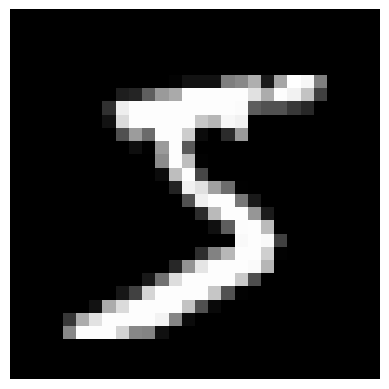

In [3]:
img0 = x_train[0].reshape(28, 28)  # 784 -> (28, 28)
plt.imshow(img0, cmap="gray")
plt.axis("off")
plt.show()

In [4]:
class MLP(nn.Module):
    def __init__(self, H=2):
        super().__init__()
        self.input_layer = nn.Linear(784, 128)
        layers = []
        for _ in range(0, H):
            layers.append(nn.Linear(128, 128))
        self.hidden_layers = nn.ModuleList(layers)
        self.output_layer = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.input_layer(x))
        for layer in self.hidden_layers:
            x = F.relu(layer(x))
        return self.output_layer(x)

In [5]:
model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [6]:
print(x_train_tensor.shape, y_train_tensor.shape)
print(x_train_tensor[0], y_train_tensor[0])

torch.Size([60000, 784]) torch.Size([60000])
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0

In [7]:
loss = criterion(model(x_train_tensor), y_train_tensor)
print(loss.item())


2.3040270805358887


In [8]:
def train(model, criterion, optimizer, x_train, y_train, x_test, y_test, epochs=10):
    for epoch in range(epochs):
        for i in tqdm(range(0, len(x_train), 64)):
            x_batch = x_train[i : i + 64]
            y_batch = y_train[i : i + 64]
            model.train()
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

            model.eval()
            with torch.no_grad():
                test_output = model(x_test)
                test_loss = criterion(test_output, y_test)
                pred = test_output.argmax(dim=1)
                accuracy = (pred == y_test).float().mean().item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}, Accuracy: {accuracy:.4f}")

In [9]:
train(model, criterion, optimizer, x_train_tensor, y_train_tensor, x_test_tensor, y_test_tensor)

100%|████████████████████████████████████████████████████████████████████████████████| 938/938 [02:08<00:00,  7.29it/s]


Epoch 1/10, Loss: 2.0108, Test Loss: 1.9773, Accuracy: 0.5530


100%|████████████████████████████████████████████████████████████████████████████████| 938/938 [01:17<00:00, 12.14it/s]


Epoch 2/10, Loss: 0.4188, Test Loss: 0.5596, Accuracy: 0.8311


100%|████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.21it/s]


...

Epoch 8/10, Loss: 0.0801, Test Loss: 0.2391, Accuracy: 0.9293


100%|████████████████████████████████████████████████████████████████████████████████| 938/938 [01:19<00:00, 11.76it/s]


Epoch 9/10, Loss: 0.0692, Test Loss: 0.2180, Accuracy: 0.9368


100%|████████████████████████████████████████████████████████████████████████████████| 938/938 [01:14<00:00, 12.51it/s]


Epoch 10/10, Loss: 0.0615, Test Loss: 0.1996, Accuracy: 0.9429


In [10]:
m = nn.Softmax(dim=-1)
torch.argmax(m(model.forward(x_train_tensor[0])))
print(m(model.forward(x_train_tensor[0])))

tensor([2.6868e-03, 3.1764e-06, 2.4720e-04, 2.7299e-01, 2.4315e-08, 7.2233e-01,
        1.0247e-07, 7.9245e-05, 1.3498e-03, 3.1259e-04],
       grad_fn=<SoftmaxBackward0>)


In [11]:
def predicted_details(res):
    for prob in res:
        print(f"{np.where(res == prob)[0][0]}: {prob*100:.2f}%")

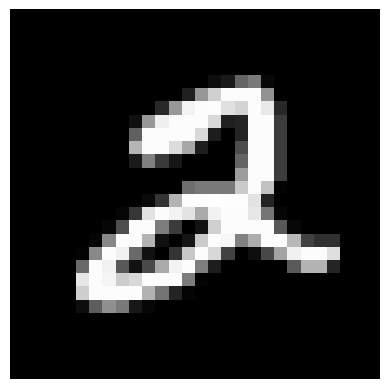

0: 0.01%
1: 0.00%
2: 96.44%
3: 2.07%
4: 0.00%
5: 0.00%
6: 0.00%
7: 0.16%
8: 1.27%
9: 0.05%
predicted: 2 actual: 2


In [12]:
k = 5
img0 = x_train[k].reshape(28, 28)  # 784 -> (28, 28)
plt.imshow(img0, cmap="gray")
plt.axis("off")
plt.show()
result = m(model.forward(x_train_tensor[k]))
predicted_details(result.detach().numpy().astype(np.float32))
print("predicted:", torch.argmax(result).item(), "actual:", y_train[k])

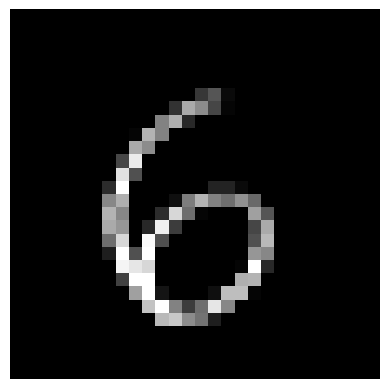

predicted: tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.], grad_fn=<SoftmaxBackward0>)


In [15]:
img = Image.open("6_test.png")
img = img.resize((28, 28)).convert("L")  # Redimensionner et convertir en niveaux de gris
img_array = np.array(img).reshape(-1)  # Convertir en tableau 1D
plt.imshow(img_array.reshape(28, 28), cmap="gray")
plt.axis("off")
plt.show()
print("predicted:", m(model.forward(torch.tensor(img_array, dtype=torch.float32))))

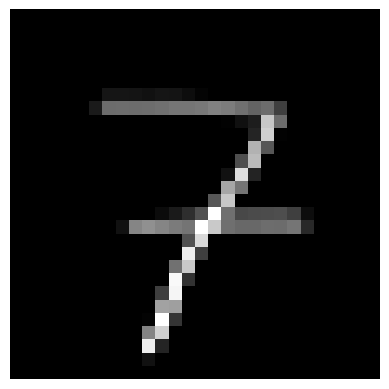

0: 0.00%
0: 0.00%
0: 0.00%
0: 0.00%
0: 0.00%
0: 0.00%
0: 0.00%
7: 100.00%
0: 0.00%
0: 0.00%
predicted: 7 actual: 7


In [52]:
from PIL import Image

img7 = Image.open("7_transformed.png")
img7_array = np.array(img7.resize((28, 28)).convert("L")).reshape(-1)
plt.imshow(img7_array.reshape(28, 28), cmap="gray")
plt.axis("off")
plt.show()
result = m(model.forward(torch.tensor(img7_array, dtype=torch.float32)))
predicted_details(result.detach().numpy().astype(np.float32))
print("predicted:", torch.argmax(result).item(), "actual: 7")

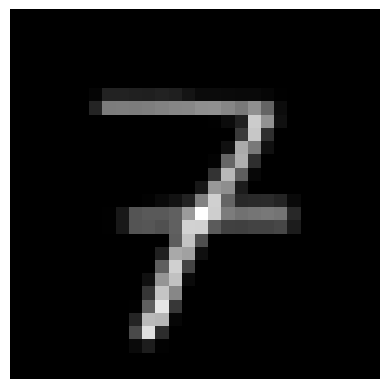

predicted: tensor(7)


In [24]:
img7_normalized = Image.open("7_mnist_normalized.png")
img7_normalized_array = np.array(img7_normalized).reshape(-1)
plt.imshow(img7_normalized_array.reshape(28, 28), cmap="gray")
plt.axis("off")
plt.show()
print("predicted:", torch.argmax(m(model.forward(torch.tensor(img7_normalized_array, dtype=torch.float32)))))